In [1]:
# import osmnx as ox
import warnings
import sys
import os

import requests
import geopandas as gpd
import pandas as pd
from popframe.models.region import Region
from popframe.method.anchor_settlement import AnchorSettlementBuilder
from typing import Dict, List, Optional, Union
import time

warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')


In [ ]:
import requests
import geopandas as gpd

API_URL = "http://10.32.1.102:5510/provision/{region_id}/get_evaluation"


def fetch_gdf(region_id: int, level: int, social_group_id: int):
    params = {
        "region_id": region_id,
        "level": level,
        "social_group_id": social_group_id,
    }

    # Делаем GET-запрос с новыми параметрами
    response = requests.get(API_URL.format(region_id=region_id), params=params)
    if response.status_code == 200:
        data = response.json()
        # Преобразуем GeoJSON-фичи в GeoDataFrame и оставляем только нужные колонки
        gdf = gpd.GeoDataFrame.from_features(data["features"])
        gdf= gdf.set_crs(4326)
        gdf = gdf.to_crs(32636)
        return gdf
    else:
        raise Exception(f"API request failed with status {response.status_code}")



In [3]:
# Параметры
region_id = 1
level = 4
social_group_id = 1

# Вызов функции
gdf = fetch_gdf(region_id, level, social_group_id)

# Посмотрим первые строки
gdf.head()

,geometry,Парк,territory_id,Поликлиника,Аптека,Больница,Многофункциональные центры предоставления государственных и муниципальных услуг,Музей,Театр,Зоопарк,...,Почтовое отделение,Отделение банка,Адвокат,Парикмахер,Салон красоты,База отдыха,Обеспеченность,basic,additional,comfort
0,"POLYGON ((34.42169 59.68391, 34.42428 59.6715,...",0.87,3,0.14,0.32,0.00,0.17,0.98,0.0,0.0,...,0.00,0.72,0.58,0.24,0.06,0.25,0.31,0.27,0.59,0.00
1,"POLYGON ((34.30682 59.71494, 34.30791 59.71295...",0.50,4,0.00,0.00,0.00,0.00,0.98,0.0,0.0,...,0.00,0.39,0.12,0.00,0.00,0.00,0.19,0.13,0.45,0.00
2,"POLYGON ((34.14251 59.48759, 34.13616 59.49064...",1.00,5,1.00,1.00,0.78,0.24,1.00,0.0,0.0,...,0.31,1.00,1.00,1.00,0.48,0.00,0.66,0.73,0.97,0.08
3,"POLYGON ((34.05997 59.15087, 34.06007 59.14658...",0.96,6,0.48,0.53,0.00,0.73,0.92,0.0,0.0,...,0.00,0.87,0.00,0.47,0.00,0.00,0.41,0.42,0.72,0.00
4,"POLYGON ((34.06836 59.40315, 34.05535 59.40393...",1.00,7,0.97,0.98,0.19,0.47,1.00,0.0,0.0,...,0.41,1.00,0.26,0.96,0.60,0.00,0.61,0.74,0.90,0.00


In [2]:
import requests
import geopandas as gpd
import pandas as pd
from tqdm import tqdm  # tqdm для прогресса

API_URL = "http://10.32.1.102:5510/provision/{region_id}/get_evaluation"

def fetch_gdf(region_id: int, level: int, social_group_id: int) -> gpd.GeoDataFrame:
    params = {
        "region_id": region_id,
        "level": level,
        "social_group_id": social_group_id,
    }
    resp = requests.get(API_URL.format(region_id=region_id), params=params)
    resp.raise_for_status()
    data = resp.json()
    gdf = gpd.GeoDataFrame.from_features(data["features"])
    return gdf.set_crs(4326).to_crs(32636)

social_groups = [
    {"soc_group_id": 1,  "name": "Подростки младшего возраста (14-15)"},
    {"soc_group_id": 2,  "name": "Подростки старшего возраста (16-17)"},
    {"soc_group_id": 3,  "name": "Трудоспособные горожане (18-59)"},
    {"soc_group_id": 4,  "name": "Люди старшего возраста (60-75)"},
    {"soc_group_id": 5,  "name": "Люди преклонного возраста (старше 75)"},
    {"soc_group_id": 6,  "name": "Горожане, ожидающие ребенка"},
    {"soc_group_id": 7,  "name": "Горожане с младенцами"},
    {"soc_group_id": 8,  "name": "Горожане с детьми детсадовского возраста (1-6 лет)"},
    {"soc_group_id": 9,  "name": "Горожане с детьми младшего школьного возраста (7-13 лет)"},
    {"soc_group_id": 10, "name": "Горожане с подростками (14-18 лет)"},
    {"soc_group_id": 11, "name": "Христиане"},
    {"soc_group_id": 12, "name": "Мусульмане"},
    {"soc_group_id": 13, "name": "Иудеи"},
    {"soc_group_id": 14, "name": "Буддисты"},
    {"soc_group_id": 15, "name": "Студенты и учащиеся колледжей"},
    {"soc_group_id": 16, "name": "Горожане с питомцами"},
]

region_id = 1
level = 4

# 1) Базовая таблица с геометрией
first = social_groups[0]
gdf_base = fetch_gdf(region_id, level, first["soc_group_id"])
gdf_final = gdf_base[["territory_id", "geometry"]].copy()

metrics = ["Обеспеченность", "basic", "additional", "comfort"]

# 2) Перебираем все группы с прогресс-баром
for grp in tqdm(social_groups, desc="Обработка соц-групп"):
    gid  = grp["soc_group_id"]
    name = grp["name"]

    gdf_i = fetch_gdf(region_id, level, gid)
    df_i = gdf_i[["territory_id"] + metrics].copy()

    # Переименование колонок
    df_i = df_i.rename(columns={
        "Обеспеченность":            f"{name} - Обеспеченность",
        "basic":                     f"{name} - Обеспеченность - basic",
        "additional":                f"{name} - Обеспеченность - additional",
        "comfort":                   f"{name} - Обеспеченность - comfort",
    })

    # Сливаем по territory_id
    gdf_final = gdf_final.merge(df_i, on="territory_id", how="left")

# 3) Преобразуем в GeoDataFrame и задаём CRS
gdf_final = gpd.GeoDataFrame(gdf_final, geometry="geometry", crs=gdf_base.crs)
gdf_final.to_file('prov.geojson')
# Готово!
gdf_final


,territory_id,geometry,Подростки младшего возраста (14-15) - Обеспеченность,Подростки младшего возраста (14-15) - Обеспеченность - basic,Подростки младшего возраста (14-15) - Обеспеченность - additional,Подростки младшего возраста (14-15) - Обеспеченность - comfort,Подростки старшего возраста (16-17) - Обеспеченность,Подростки старшего возраста (16-17) - Обеспеченность - basic,Подростки старшего возраста (16-17) - Обеспеченность - additional,Подростки старшего возраста (16-17) - Обеспеченность - comfort,...,Буддисты - Обеспеченность - additional,Буддисты - Обеспеченность - comfort,Студенты и учащиеся колледжей - Обеспеченность,Студенты и учащиеся колледжей - Обеспеченность - basic,Студенты и учащиеся колледжей - Обеспеченность - additional,Студенты и учащиеся колледжей - Обеспеченность - comfort,Горожане с питомцами - Обеспеченность,Горожане с питомцами - Обеспеченность - basic,Горожане с питомцами - Обеспеченность - additional,Горожане с питомцами - Обеспеченность - comfort
0,3,"POLYGON ((580049.515 6617067.72, 580225.344 66...",0.31,0.27,0.59,0.00,0.29,0.27,0.59,0.00,...,0.59,0.00,0.30,0.27,0.59,0.00,0.30,0.27,0.59,0.00
1,4,"POLYGON ((573514.444 6620389.851, 573579.919 6...",0.19,0.13,0.45,0.00,0.18,0.13,0.45,0.00,...,0.45,0.00,0.18,0.13,0.45,0.00,0.18,0.13,0.45,0.00
2,5,"POLYGON ((564707.328 6594903.594, 564341.814 6...",0.66,0.73,0.97,0.08,0.62,0.73,0.97,0.07,...,0.97,0.08,0.64,0.73,0.97,0.07,0.64,0.73,0.97,0.08
3,6,"POLYGON ((560629.509 6557332.762, 560642.857 6...",0.41,0.42,0.72,0.00,0.38,0.42,0.72,0.00,...,0.72,0.00,0.39,0.42,0.72,0.00,0.39,0.42,0.72,0.00
4,7,"POLYGON ((560659.317 6585430.874, 559919.213 6...",0.61,0.74,0.90,0.00,0.60,0.74,0.90,0.10,...,0.90,0.00,0.61,0.74,0.90,0.10,0.60,0.74,0.90,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,202,"POLYGON ((360431.648 6619592.469, 360583.132 6...",0.56,0.49,0.88,0.21,0.56,0.49,0.88,0.34,...,0.88,0.21,0.58,0.49,0.88,0.34,0.55,0.49,0.88,0.21
183,203,"POLYGON ((387941.398 6612286.59, 388009.665 66...",0.55,0.54,0.88,0.20,0.54,0.54,0.88,0.33,...,0.88,0.20,0.56,0.54,0.88,0.33,0.53,0.54,0.88,0.20
184,204,"POLYGON ((363803.737 6614904.469, 363821.597 6...",0.66,0.76,0.88,0.20,0.65,0.76,0.88,0.33,...,0.88,0.20,0.67,0.76,0.88,0.33,0.67,0.76,0.88,0.20
185,205,"POLYGON ((392924.072 6551507.217, 393174.409 6...",0.25,0.22,0.52,0.22,0.25,0.22,0.52,0.25,...,0.52,0.22,0.25,0.22,0.52,0.25,0.24,0.22,0.52,0.22


In [9]:
for grp in tqdm(social_groups, desc="Обработка соц-групп"):
    name = grp["name"]

    gdf_final = gdf_final.rename(columns={
        f"{name} - Обеспеченность":                             f"{name} - Неравенство",
        f"{name} - Обеспеченность - basic":                     f"{name} - Неравенство - basic",
        f"{name} - Обеспеченность - additional":                f"{name} - Неравенство - additional",
        f"{name} - Обеспеченность - comfort":                   f"{name} - Неравенство - comfort",
    })

In [16]:
gdf_final.head(4)

,territory_id,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Буддисты - Неравенство - additional,Буддисты - Неравенство - comfort,Студенты и учащиеся колледжей - Неравенство,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort
0,3,"POLYGON ((580049.515 6617067.72, 580225.344 66...",0.69,0.73,0.41,1.00,0.71,0.73,0.41,1.00,...,0.41,1.00,0.70,0.73,0.41,1.00,0.70,0.73,0.41,1.00
1,4,"POLYGON ((573514.444 6620389.851, 573579.919 6...",0.81,0.87,0.55,1.00,0.82,0.87,0.55,1.00,...,0.55,1.00,0.82,0.87,0.55,1.00,0.82,0.87,0.55,1.00
2,5,"POLYGON ((564707.328 6594903.594, 564341.814 6...",0.34,0.27,0.03,0.92,0.38,0.27,0.03,0.93,...,0.03,0.92,0.36,0.27,0.03,0.93,0.36,0.27,0.03,0.92
3,6,"POLYGON ((560629.509 6557332.762, 560642.857 6...",0.59,0.58,0.28,1.00,0.62,0.58,0.28,1.00,...,0.28,1.00,0.61,0.58,0.28,1.00,0.61,0.58,0.28,1.00


In [13]:
# Найти все столбцы, кроме geometry
cols = gdf_final.columns.difference(['geometry', 'territory_id'])

# Применить к ним преобразование: новое значение = 1 − старое
gdf_final[cols] = 1 - gdf_final[cols]

In [20]:
gdf_final.head(3)

,territory_id,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Буддисты - Неравенство - additional,Буддисты - Неравенство - comfort,Студенты и учащиеся колледжей - Неравенство,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort
0,3,"POLYGON ((580049.515 6617067.72, 580225.344 66...",0.69,0.73,0.41,1.00,0.71,0.73,0.41,1.00,...,0.41,1.00,0.70,0.73,0.41,1.00,0.70,0.73,0.41,1.00
1,4,"POLYGON ((573514.444 6620389.851, 573579.919 6...",0.81,0.87,0.55,1.00,0.82,0.87,0.55,1.00,...,0.55,1.00,0.82,0.87,0.55,1.00,0.82,0.87,0.55,1.00
2,5,"POLYGON ((564707.328 6594903.594, 564341.814 6...",0.34,0.27,0.03,0.92,0.38,0.27,0.03,0.93,...,0.03,0.92,0.36,0.27,0.03,0.93,0.36,0.27,0.03,0.92


In [ ]:
# gdf_final.to_file('spatial_inequality_LO.geojson', driver='GeoJSON')

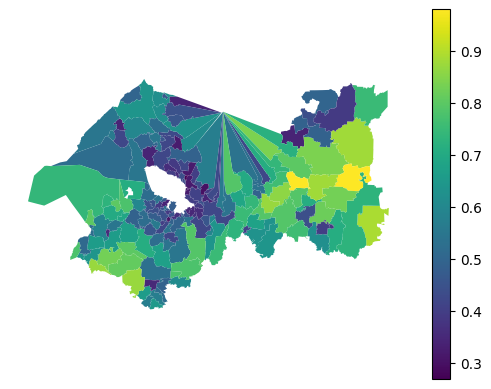

In [14]:
gdf_final.plot('Подростки старшего возраста (16-17) - Неравенство', legend=True).set_axis_off()

In [21]:
import folium

def create_interactive_map(final_gdf):
    """
    Создает интерактивную карту с серой подложкой и отдельными слоями
    для каждой соц группы и типа неравенства, которые пользователь
    может включать через LayerControl.
    """
    # Приведение CRS к WGS84
    if final_gdf.crs != "EPSG:4326":
        final_gdf = final_gdf.to_crs(epsg=4326)

    # Начальная карта
    m = folium.Map(
        location=[final_gdf.geometry.centroid.y.mean(), final_gdf.geometry.centroid.x.mean()],
        zoom_start=10
    )

    # Серый базовый слой
    base_layer = folium.FeatureGroup(name='Базовый (серый)', show=True)
    folium.GeoJson(
        final_gdf,
        style_function=lambda feature: {
            'fillColor': 'lightgray',
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.4
        }
    ).add_to(base_layer)
    base_layer.add_to(m)

    # Список соц групп и типов
    social_groups = [
        "Подростки младшего возраста (14-15)",
        "Подростки старшего возраста (16-17)",
        "Трудоспособные горожане (18-59)",
        "Люди старшего возраста (60-75)",
        "Люди преклонного возраста (старше 75)",
        "Горожане, ожидающие ребенка",
        "Горожане с младенцами",
        "Горожане с детьми детсадовского возраста (1-6 лет)",
        "Горожане с детьми младшего школьного возраста (7-13 лет)",
        "Горожане с подростками (14-18 лет)",
        "Христиане",
        "Мусульмане",
        "Иудеи",
        "Буддисты",
        "Студенты и учащиеся колледжей",
        "Горожане с питомцами"
    ]
    types = ["Неравенство", "basic", "additional", "comfort"]

    # Для каждой комбинации создаем слой
    for group in social_groups:
        for t in types:
            # Формируем имя атрибута с учётом фактического шаблона
            if t == "Неравенство":
                attr = f"{group} - Неравенство"
            else:
                attr = f"{group} - Неравенство - {t}"

            # Пропускаем, если столбец отсутствует
            if attr not in final_gdf.columns:
                continue

            # Вычисляем диапазон значений
            vals = final_gdf[attr].dropna()
            if vals.empty:
                continue
            vmin, vmax = vals.min(), vals.max()

            # Создаем цветовую шкалу
            colormap = folium.LinearColormap(['yellow', 'orange', 'red'], vmin=vmin, vmax=vmax)
            colormap.caption = attr

            # Создаем слой
            layer = folium.FeatureGroup(name=attr, show=False)
            folium.GeoJson(
                final_gdf,
                style_function=lambda feature, cmap=colormap, key=attr: {
                    'fillColor': cmap(feature['properties'].get(key, 0)),
                    'color': 'black',
                    'weight': 0.5,
                    'fillOpacity': 0.7
                },
                tooltip=folium.GeoJsonTooltip(fields=[attr], aliases=[attr])
            ).add_to(layer)
            layer.add_to(m)

    # Добавляем контрол переключения слоев
    folium.LayerControl(collapsed=False).add_to(m)

    return m

In [ ]:
# Пример вызова
m = create_interactive_map(gdf_final)
m